## Import Libraries

In [ ]:
import os
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal
from scipy.stats import friedmanchisquare
from sklearn.feature_selection import mutual_info_regression

In [ ]:
session, scan, field = 6, 6, 2

sign_constraint = False # Whether to apply a sign constraint on the weights
use_only_sttc = False # Whether to use only STTC for the bio weights
use_precison_matrix = False # Whether to use the precision matrix for the bio weights


model = 'W*D*C'  #choose the model

base = f'{session}_{scan}_{field}_sttc'
if not use_only_sttc:
    base += '-precision' if use_precison_matrix else '-corr'
if sign_constraint:
    base += '_sign+'
folder_name = f'/content/data/simu/{base}'


In [ ]:
metrics = ['Accuracy', 'Assortativity', 'Entropy', 'Loss', 'Modularity', 'SmallWorldness', 'Validation_Accuracy', 'Validation_Loss']

## Predefined Functions

In [ ]:
def draw_olumn_disturbutions(df):
  for col in df.columns:

    plt.figure(figsize=(6,4))

    plt.hist(df[col], bins=10, alpha=0.5, density=True)

    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
def captures_non_linear_dependencies(df, metric):
  target = df[metric]
  features = df.drop(columns=[metric])
  mi_scores = mutual_info_regression(features, target)
  return pd.Series(mi_scores, index=features.columns).sort_values(ascending=False)

## Load Datasets

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/ISP

Papers	simu.zip


In [ ]:
!unzip /content/drive/MyDrive/ISP/simu.zip -d /content/data

Archive:  /content/drive/MyDrive/ISP/simu.zip
   creating: /content/data/simu/
   creating: /content/data/simu/5_6_8_sttc-precision_sign+/
  inflating: /content/data/__MACOSX/simu/._5_6_8_sttc-precision_sign+  
  inflating: /content/data/simu/.DS_Store  
  inflating: /content/data/__MACOSX/simu/._.DS_Store  
   creating: /content/data/simu/5_6_8_sttc-corr_sign+/
  inflating: /content/data/__MACOSX/simu/._5_6_8_sttc-corr_sign+  
   creating: /content/data/simu/5_3_4_sttc-corr/
  inflating: /content/data/__MACOSX/simu/._5_3_4_sttc-corr  
   creating: /content/data/simu/5_3_4_sttc-corr_sign+/
  inflating: /content/data/__MACOSX/simu/._5_3_4_sttc-corr_sign+  
   creating: /content/data/simu/5_3_4_sttc-precision_sign+/
  inflating: /content/data/__MACOSX/simu/._5_3_4_sttc-precision_sign+  
   creating: /content/data/simu/6_6_2_sttc-precision_sign+/
  inflating: /content/data/__MACOSX/simu/._6_6_2_sttc-precision_sign+  
   creating: /content/data/simu/6_6_2_sttc-precision/
  inflating: /cont

In [ ]:
print(os.listdir("/content/data/simu"))

['plotting.ipynb', '.DS_Store', '5_3_4_sttc-precision_sign+', '6_6_2_sttc-precision', '6_6_2_sttc-corr', '5_6_8_sttc-precision', '5_6_8_sttc-corr_sign+', 'rcc.ipynb', '6_6_2_sttc-corr_sign+', '5_3_4_sttc-precision', '5_6_8_sttc-corr', '6_6_2_sttc-precision_sign+', '5_6_8_sttc-precision_sign+', '5_3_4_sttc-corr', '5_3_4_sttc-corr_sign+']


In [ ]:
model_columns = []

for i, metric in enumerate( metrics):
  df = pd.read_csv(f'{folder_name}/Task1/{metric}_raw.csv')
  col = df[model].rename(metric)
  model_columns.append(col)


final_df = pd.concat(model_columns, axis=1)

print(final_df)

    Accuracy  Assortativity   Entropy      Loss  Modularity  SmallWorldness  \
0   1.000000      -0.051992  0.801269  0.053901    0.472607        2.254178   
1   1.000000       0.061169  1.915917  0.090934    0.559405        2.491821   
2   0.694531      -0.093343  2.027120  1.549415    0.504541        2.247430   
3   0.762500      -0.079137  2.166722  1.239510    0.397618        1.947331   
4   1.000000       0.010076  0.601358  0.056338    0.497746        1.572843   
5   1.000000      -0.075345  2.180945  0.128120    0.512475        2.291738   
6   1.000000       0.006688  1.169902  0.033062    0.474200        2.193983   
7   1.000000      -0.074426  0.416885  0.039519    0.476577        1.719108   
8   0.730273      -0.069154  1.883324  1.517336    0.427865        2.099219   
9   0.632031       0.118736  0.548208  0.579363    0.499078        1.507670   
10  0.643359      -0.265384  2.136875  1.538043    0.301284        2.036707   
11  1.000000       0.001381  1.985371  0.256323    0

In [ ]:
final_df.describe()

,Accuracy,Assortativity,Entropy,Loss,Modularity,SmallWorldness,Validation_Accuracy,Validation_Loss
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,0.916777,-0.041062,1.354000,0.441463,0.466270,2.114176,0.918711,0.419202
std,0.136620,0.092112,0.624865,0.571426,0.057476,0.325210,0.129860,0.508470
min,0.632031,-0.265384,0.416885,0.029944,0.301284,1.507670,0.618359,0.028602
25%,0.891406,-0.082689,0.752838,0.048696,0.446517,1.936442,0.872656,0.045655
50%,1.000000,-0.044133,1.387538,0.109527,0.474679,2.183932,1.000000,0.103948
75%,1.000000,0.007535,1.933281,0.664807,0.498079,2.387140,1.000000,0.906647
max,1.000000,0.126536,2.180945,1.549415,0.559405,2.496380,1.000000,1.406358


/tmp/ipython-input-2554524305.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


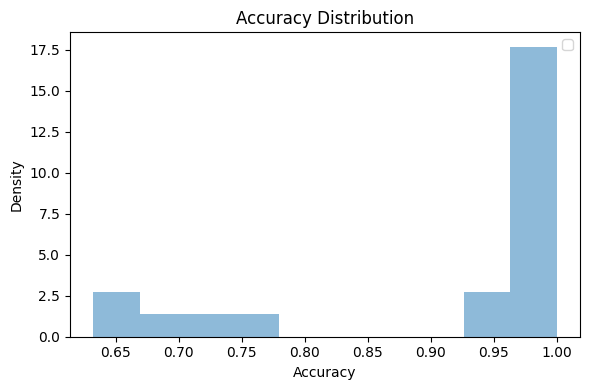

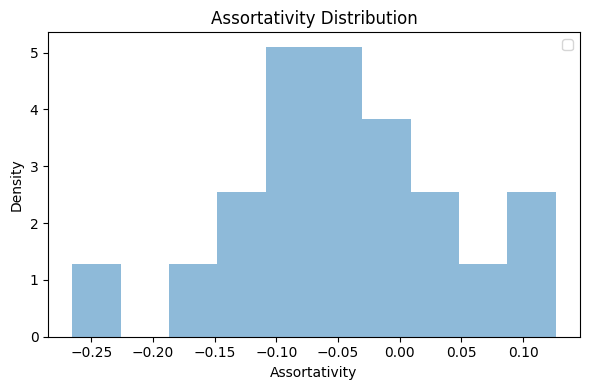

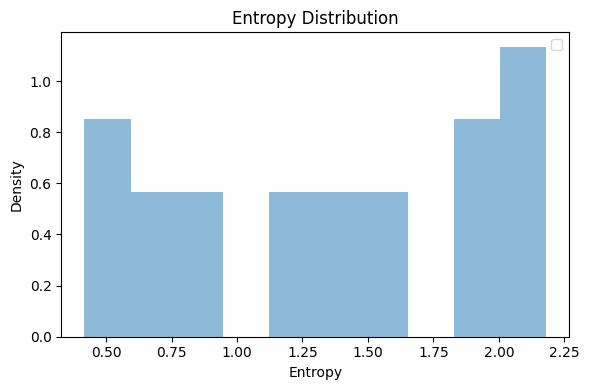

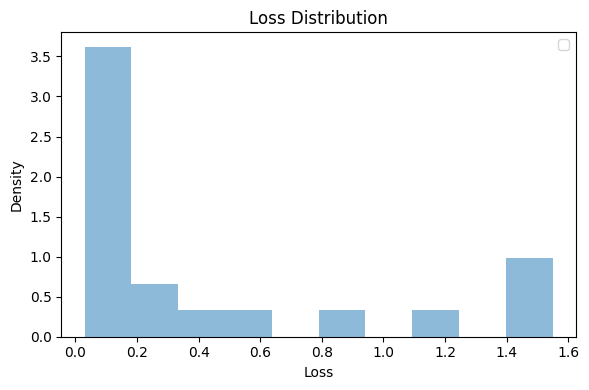

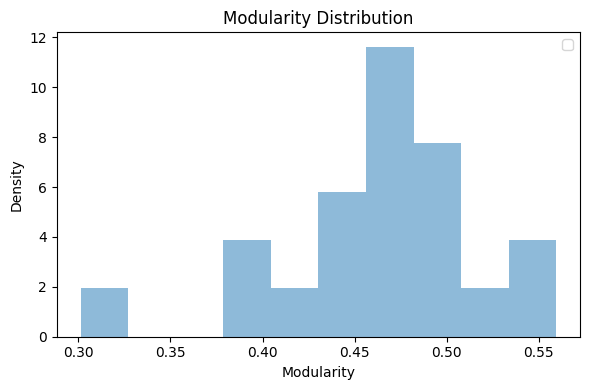

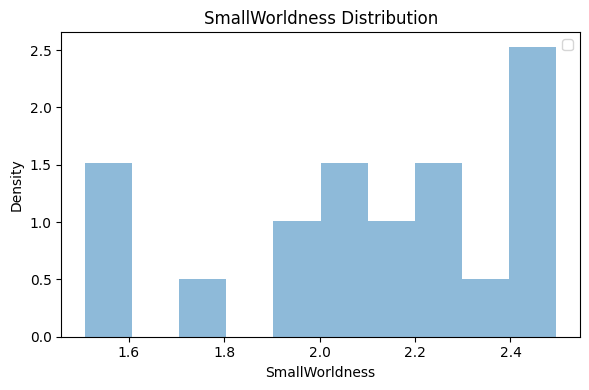

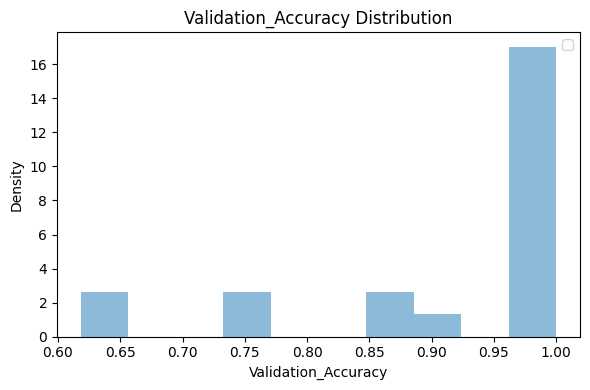

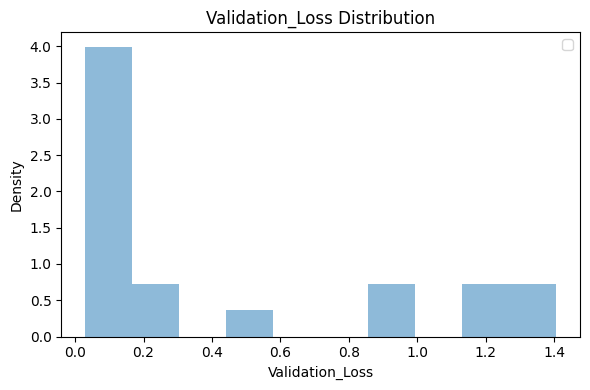

In [ ]:
draw_olumn_disturbutions(final_df)

<Axes: >

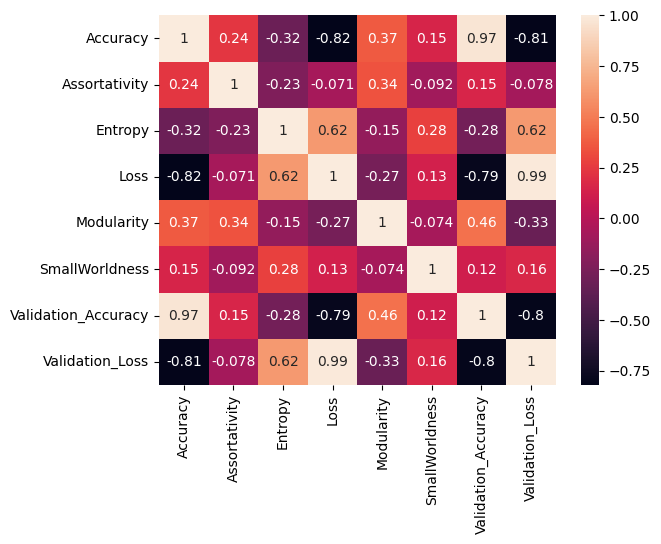

In [ ]:
corr_spearman = final_df.corr(method='spearman')
sns.heatmap(corr_spearman, annot=True)

In [ ]:
captures_non_linear_dependencies(final_df, 'SmallWorldness')

,0
Accuracy,0.188983
Loss,0.167118
Validation_Accuracy,0.054477
Modularity,0.051238
Validation_Loss,0.014011
Entropy,0.000000
Assortativity,0.000000


In [ ]:
captures_non_linear_dependencies(final_df, 'Entropy')

,0
Loss,0.176277
Accuracy,0.117450
Modularity,0.097656
Validation_Loss,0.084905
Assortativity,0.043569
SmallWorldness,0.000000
Validation_Accuracy,0.000000
